<a href="https://colab.research.google.com/github/JjKkhld/Pandas/blob/main/supermarket_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librares and data import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import style
import seaborn as sns

plt.style.use('tableau-colorblind10')

# data source: https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales

data = pd.read_csv('/content/drive/MyDrive/DataFrames/supermarket_sales.csv')

data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


# I. Cleaning data - Total records, data type expectation and changing dtypes, Missing Values

## 1. Total records

In [ ]:
print('Number of rows: {}'.format(data.shape[0]))
print('Number of columns: {}'.format(data.shape[1]))
print('Columns in data: {}'.format(data.columns.values))

Number of rows: 1000
Number of columns: 17
Columns in data: ['Invoice ID' 'Branch' 'City' 'Customer type' 'Gender' 'Product line'
 'Unit price' 'Quantity' 'Tax 5%' 'Total' 'Date' 'Time' 'Payment' 'cogs'
 'gross margin percentage' 'gross income' 'Rating']


## 2. Columns describing

* **Invoice id**: Computer generated sales slip invoice identification number
* **Branch**: Branch of supercenter (3 branches are available identified by A, B and C).
* **City**: Location of supercenters
* **Customer type**: Type of customers, recorded by Members for customers using member card and Normal for without member card.
* **Gender**: Gender type of customer
* **Product line**: General item categorization groups - Electronic accessories, Fashion accessories, Food and beverages, Health and beauty, Home and lifestyle, Sports and travel
* **Unit price**: Price of each product in $
* **Quantity**: Number of products purchased by customer
* **Tax**: 5% tax fee for customer buying
* **Total**: Total price including tax
* **Date**: Date of purchase (Record available from January 2019 to March 2019)
* **Time**: Purchase time (10am to 9pm)
* **Payment**: Payment used by customer for purchase (3 methods are available – Cash, Credit card and Ewallet)
* **COGS**: Cost of goods sold
* **Gross margin percentage**: Gross margin percentage
* **Gross income**: Gross income
* **Rating**: Customer stratification rating on their overall shopping experience (On a scale of 1 to 10)

## 3. Data type expectation

* **Invoice id**: str / obj
* **Branch**: str / obj
* **City**: str / obj (region)
* **Customer type**: str / obj
* **Gender**: str / obj
* **Product line**: str / obj
* **Unit price**: float
* **Quantity**: int / float
* **Tax**: float
* **Total**: float
* **Date**: date
* **Time**: time
* **Payment**: str / obj
* **COGS**: float
* **Gross margin percentage**: float
* **Gross income**: float
* **Rating**: float

In [ ]:
# cheking of the data type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

So it's necessary to change dtype of the 'Date' and 'Time' columns

## 4. Changing dtypes

Let's create a new celumns 'Date_time' by combine the col 'Date' and 'Time'

In [ ]:
# creating a new col 'Date_time'
data['Date_time'] = data['Date'] + ' ' + data['Time'].apply(lambda x: x + ':00')

# converting to datetime
data['Date_time'] = pd.to_datetime(data['Date_time'])

# drop cols 'Date' and 'Time'
data.drop(['Date', 'Time'], axis=1, inplace=True)

# check dtype
print("The type of the 'Date_time' is {}".format(data['Date_time'].dtypes))

The type of the 'Date_time' is datetime64[ns]


In [ ]:
print("So we have {} columns now".format(data.shape[1]))

So we have 16 columns now


Here we can check if dtypes are appropriate:

In [ ]:
# selct numeric columns
data_num = data.select_dtypes(include=[np.number])
print("Numeric columns are: {}; and length is {}."\
      .format(data_num.columns.values, len(data_num.columns.values)))

# selct non-numeric columns
data_non = data.select_dtypes(exclude=[np.number])
print("Numeric columns are: {}; and length is {}."\
      .format(data_non.columns.values, len(data_non.columns.values)))

Numeric columns are: ['Unit price' 'Quantity' 'Tax 5%' 'Total' 'cogs' 'gross margin percentage'
 'gross income' 'Rating']; and length is 8.
Numeric columns are: ['Invoice ID' 'Branch' 'City' 'Customer type' 'Gender' 'Product line'
 'Payment' 'Date_time']; and length is 8.


## 5. Missing Value Check & Duplication Checks

In [ ]:
values_are_null = data.isna().sum()
values_are_null

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Date_time                  0
dtype: int64

There are not the miss values

# II. Making analysis

## 1. Sales Performance Analysis

### 1.1 Calculating total sales revenue over different time periods (daily, weekly, monthly) using 'Total' column.

In [ ]:
print("The first day in data: {}".format(data['Date_time'].min()))
print("The last day in data: {}".format(data['Date_time'].max()))

The first day in data: 2019-01-01 10:39:00
The last day in data: 2019-03-30 20:37:00


In [ ]:
# preparing a new df
data_calendar = data[['Date_time', 'Total']].sort_values(by='Date_time')

# creating a function which must give a name of the months
def name_of_months(row):
  if row == 1:
    return 'January'
  elif row == 2:
    return 'February'
  else:
    return 'March'

# adding new columns 'Week', 'Months' and 'Day'
data_calendar['Week'] = data_calendar['Date_time'].dt.isocalendar().week
data_calendar['Month'] = data_calendar['Date_time'] \
                        .dt.month.apply(name_of_months)
data_calendar['Day'] = data_calendar['Date_time'].dt.date

Now let's group this df

In [ ]:
grouped_by_days = data_calendar.groupby('Day', as_index=False).agg({'Total' : 'sum'})
grouped_by_weeks = data_calendar.groupby('Week', as_index=False).agg({'Total' : 'sum'})
grouped_by_months = data_calendar.groupby('Month', as_index=False).agg({'Total' : 'sum'}) \
                                  .reindex([1, 0, 2]).reset_index(drop=True)

In [ ]:
grouped_by_days.head(5)

,Day,Total
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


In [ ]:
grouped_by_weeks.head(5)

,Week,Total
0,1,17543.3895
1,2,24461.1990
2,3,28693.3605
3,4,29286.8835
4,5,28360.4475


In [ ]:
grouped_by_months.head()

,Month,Total
0,January,116291.868
1,February,97219.374
2,March,109455.507


Min, max, mean for daily sales

In [ ]:
the_highest_daily_total = grouped_by_days['Total'].max()

print("The highest daily total sale was {} on {}." \
.format(round(the_highest_daily_total, 2), grouped_by_days['Day'][grouped_by_days['Total'] == the_highest_daily_total].to_string(index=False)))

the_lower_daily_total = grouped_by_days['Total'].min()

print("The lower daily total sale was {} on {}." \
.format(round(the_lower_daily_total, 2), grouped_by_days['Day'][grouped_by_days['Total'] == the_lower_daily_total].to_string(index=False)))

print("The mean of daily total sale was {}".format(round(grouped_by_days['Total'].mean(), 2)))


The highest daily total sale was 7474.05 on 2019-03-09.
The lower daily total sale was 934.24 on 2019-02-13.
The mean of daily total sale was 3628.84


Min, max, mean for weekly sales

In [ ]:
the_highest_weekly_total = grouped_by_weeks['Total'].max()

print("The highest weekly total sale was {} in {} week." \
.format(round(the_highest_weekly_total, 2), grouped_by_weeks['Week'][grouped_by_weeks['Total'] == the_highest_weekly_total].to_string(index=False)))

the_lower_weekly_total = grouped_by_weeks['Total'].min()

print("The lower weekly total sale was {} in {} week." \
.format(round(the_lower_weekly_total, 2), grouped_by_weeks['Week'][grouped_by_weeks['Total'] == the_lower_weekly_total].to_string(index=False)))

print("The mean of weekly total sale was {}".format(round(grouped_by_weeks['Total'].mean(), 2)))

The highest weekly total sale was 29286.88 in 4 week.
The lower weekly total sale was 17328.66 in 8 week.
The mean of weekly total sale was 24843.6


Min, max, mean, for monthly sales and total sales

In [ ]:
the_highest_monthly_total = grouped_by_months['Total'].max()

print("The highest monthly total sale was {} in {}." \
.format(round(the_highest_monthly_total, 2), grouped_by_months['Month'][grouped_by_months['Total'] == the_highest_monthly_total].to_string(index=False)))

the_lower_monthly_total = grouped_by_months['Total'].min()

print("The lower monthly total sale was {} in {}." \
.format(round(the_lower_monthly_total, 2), grouped_by_months['Month'][grouped_by_months['Total'] == the_lower_monthly_total].to_string(index=False)))

print("The mean of monthly total sale was {}".format(round(grouped_by_months['Total'].mean(), 2)))
print("The total sale was {}".format(round(grouped_by_months['Total'].sum(), 2)))

The highest monthly total sale was 116291.87 in January.
The lower monthly total sale was 97219.37 in February.
The mean of monthly total sale was 107655.58
The total sale was 322966.75


### 1.1 Visualization.

<BarContainer object of 89 artists>

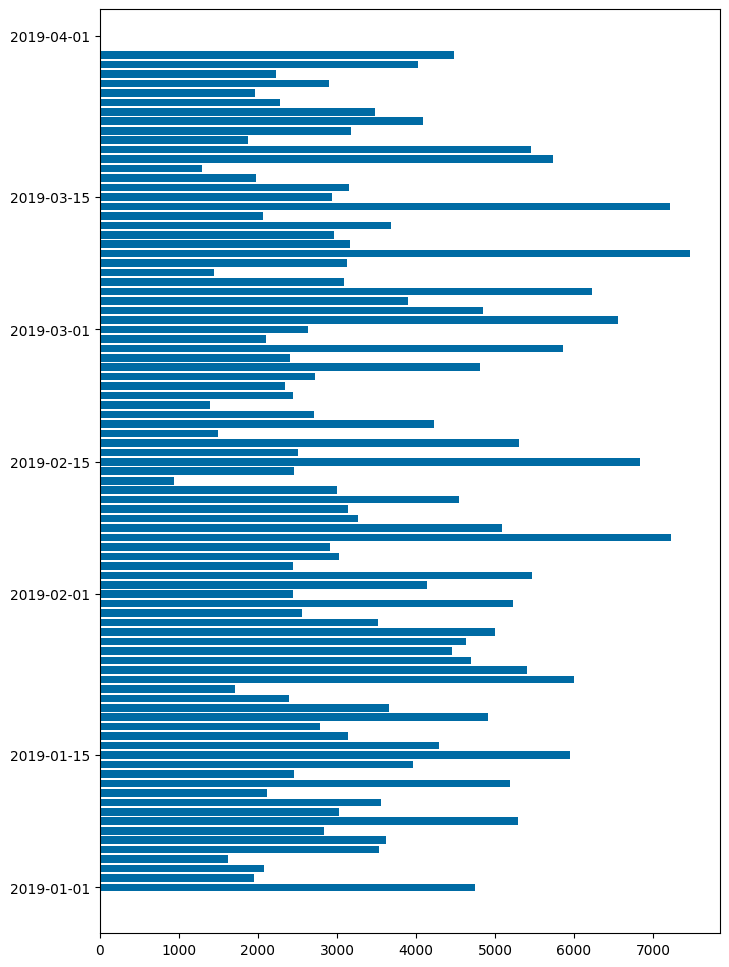

In [ ]:
figure(figsize=(8, 12), dpi=100)

plt.barh(grouped_by_days['Day'], grouped_by_days['Total'])

<BarContainer object of 13 artists>

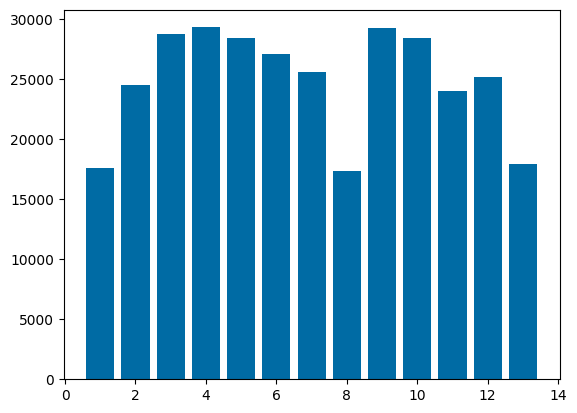

In [ ]:
plt.bar(grouped_by_weeks['Week'], grouped_by_weeks['Total'])

<BarContainer object of 3 artists>

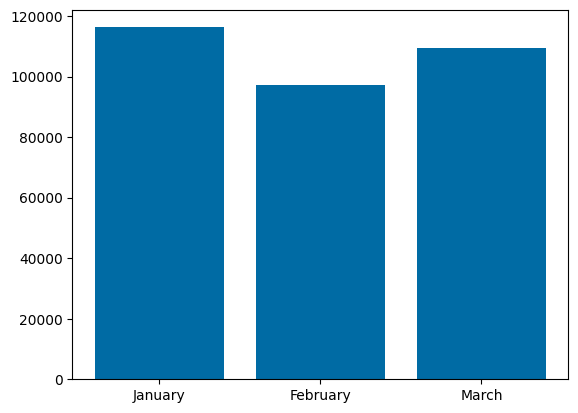

In [ ]:
plt.bar(grouped_by_months['Month'], grouped_by_months['Total'])

### 1.2 Identify top-selling 'Product line' and branches ('Branch') in terms of sales revenue.

In [ ]:
data_prodline_branch = data[['Product line', 'Branch', 'Total']]
data_prodline_branch.head(5)

,Product line,Branch,Total
0,Health and beauty,A,548.9715
1,Electronic accessories,C,80.2200
2,Home and lifestyle,A,340.5255
3,Health and beauty,A,489.0480
4,Sports and travel,A,634.3785


In [ ]:
data_prodline_branch.groupby(['Product line', 'Branch'], as_index=False) \
                    .agg({'Total' : 'sum'}) \
                    .sort_values(by='Total', ascending=False) \
                    .head(3)

,Product line,Branch,Total
8,Food and beverages,C,23766.8550
12,Home and lifestyle,A,22417.1955
5,Fashion accessories,C,21560.0700


In [ ]:
data_prodline_branch.groupby('Product line', as_index=False) \
                    .agg({'Total' : 'sum'}) \
                    .sort_values(by='Total', ascending=False) \
                    .head(3)

,Product line,Total
2,Food and beverages,56144.8440
5,Sports and travel,55122.8265
0,Electronic accessories,54337.5315


In [ ]:
data_prodline_branch.groupby('Branch', as_index=False) \
                    .agg({'Total' : 'sum'}) \
                    .sort_values(by='Total', ascending=False) \
                    .head(3)

,Branch,Total
2,C,110568.7065
0,A,106200.3705
1,B,106197.6720


So the most sale product line is **Food and beverages** (total is **56,144.844**); the most sale branch is **C** (total is **110,568.71**); the total sale from **Food and beverages from branch C is** **23,766.86**

## 2. Customer Segmentation

### 2.1 Segment customers based on demographics (age, gender, location)

In [ ]:
# Segment customers based on demographics, columns are:
# - Invoice ID
# - City
# - Gender

data_demograph = data[['Invoice ID', 'City', 'Gender', 'Total', 'cogs', 'gross income']]
data_demograph.head(5)

,Invoice ID,City,Gender,Total,cogs,gross income
0,750-67-8428,Yangon,Female,548.9715,522.83,26.1415
1,226-31-3081,Naypyitaw,Female,80.2200,76.40,3.8200
2,631-41-3108,Yangon,Male,340.5255,324.31,16.2155
3,123-19-1176,Yangon,Male,489.0480,465.76,23.2880
4,373-73-7910,Yangon,Male,634.3785,604.17,30.2085


In [ ]:
demographic_city = data_demograph.groupby('City', as_index=False) \
              .agg({'Invoice ID' : 'count', 'Total' : 'sum', 'cogs' : 'mean', 'gross income' : 'sum'}) \
              .rename(columns={"Invoice ID" : "Count", "Total" : "Total spend", "cogs" : "Average Cost", "gross income" : "Total gross income"}) \
              .sort_values(by="Count", ascending=False) \
              .reset_index(drop=True)

demographic_gender = data_demograph.groupby('Gender', as_index=False) \
              .agg({'Invoice ID' : 'count', 'Total' : 'sum', 'cogs' : 'mean', 'gross income' : 'sum'}) \
              .rename(columns={"Invoice ID" : "Count", "Total" : "Total spend", "cogs" : "Average Cost", "gross income" : "Total gross income"}) \
              .sort_values(by="Count", ascending=False) \
              .reset_index(drop=True)

In [ ]:
demographic_city

,City,Count,Total spend,Average Cost,Total gross income
0,Yangon,340,106200.3705,297.480029,5057.1605
1,Mandalay,332,106197.6720,304.640482,5057.0320
2,Naypyitaw,328,110568.7065,321.047348,5265.1765


In [ ]:
demographic_gender

,Gender,Count,Total spend,Average Cost,Total gross income
0,Female,501,167882.925,319.138723,7994.425
1,Male,499,155083.824,295.989739,7384.944


Most sales were in the Naypyitaw and it was 110,568.71. Most of the clients was from Yangon. Most of the clients was Female and the total sales in this segment is 167,882.93.

### 2.2 Analyze purchasing patterns of different customer segments.

In [ ]:
# Segment customers based on purchasing behavior, columns are:
# - Invoice ID
# - Customer type
# - Payment
# - Rating

customers_total_segm = data[['Invoice ID', 'Customer type', 'Payment', 'Total', 'gross income']] \
                      .sort_values(by='Total', ascending=False).reset_index(drop=True)

def segment_cust(row):
  if row <= customers_total_segm['Total'].describe()[4]:
    return 'Low spenders'
  if row >= customers_total_segm['Total'].describe()[6]:
    return 'High spenders'
  else:
    return 'Medium spenders'

customers_total_segm['Percentage'] = customers_total_segm['gross income'] \
            .apply(lambda x: x / customers_total_segm['gross income'].sum() * 100)

customers_total_segm['Segments'] = customers_total_segm['Total'].apply(segment_cust)

customers_total_segm.head(3)

,Invoice ID,Customer type,Payment,Total,gross income,Percentage,Segments
0,860-79-0874,Member,Credit card,1042.65,49.65,0.322835,High spenders
1,687-47-8271,Normal,Credit card,1039.29,49.49,0.321795,High spenders
2,283-26-5248,Member,Ewallet,1034.46,49.26,0.320299,High spenders


In [ ]:
customers_total_segm.groupby('Segments', as_index=False).agg({'Total' : 'count'})

,Segments,Total
0,High spenders,250
1,Low spenders,250
2,Medium spenders,500


The number of the high spenders is **250**, of the low spenders is **250** and of the medium spenders is **500**

In [ ]:
print("Number of unique invoice ID is {}; number of rows in original data is {}." \
      .format(len(customers_total_segm['Invoice ID'].unique()), data.shape[0]))

Number of unique invoice ID is 1000; number of rows in original data is 1000.


It means that each client doesn't make more than 1 purchase in this df. So it's not necessary of calculation of the average total sale for each client.

In [ ]:
customers_total_segm.groupby('Segments', as_index=False) \
                    .agg({"Total" : "sum", "gross income" : "sum", "Percentage" : "sum"}) \
                    .sort_values(by='Percentage', ascending=False) \
                    .reset_index(drop=True)

,Segments,Total,gross income,Percentage
0,High spenders,170729.1705,8129.9605,52.862770
1,Medium spenders,134474.9490,6403.5690,41.637397
2,Low spenders,17762.6295,845.8395,5.499832


The most income was from High spenders segment, it was 170,729.17 or about 52.86% in all total sales.

In [ ]:
customers_total_segm.groupby(['Segments', 'Customer type'], as_index=False) \
                    .agg({"Total" : "sum", "gross income" : "sum", "Percentage" : "sum"}) \
                    .sort_values(by='Percentage', ascending=False) \
                    .reset_index(drop=True)

,Segments,Customer type,Total,gross income,Percentage
0,High spenders,Member,89171.4810,4246.2610,27.610112
1,High spenders,Normal,81557.6895,3883.6995,25.252658
2,Medium spenders,Normal,68874.4035,3279.7335,21.325540
3,Medium spenders,Member,65600.5455,3123.8355,20.311857
4,Low spenders,Member,9451.4175,450.0675,2.926437
5,Low spenders,Normal,8311.2120,395.7720,2.573396


The most income was from Member customer type from High spenders segment, it was 89,171.48 or about 27.6% in all total sales.

In [ ]:
customers_total_segm.groupby(['Segments', 'Payment'], as_index=False) \
                    .agg({"Total" : "sum", "gross income" : "sum", "Percentage" : "sum"}) \
                    .sort_values(by='Percentage', ascending=False) \
                    .reset_index(drop=True)

,Segments,Payment,Total,gross income,Percentage
0,High spenders,Cash,59013.4965,2810.1665,18.272313
1,High spenders,Ewallet,56257.9920,2678.9520,17.419128
2,High spenders,Credit card,55457.6820,2640.8420,17.171329
3,Medium spenders,Cash,47737.3575,2273.2075,14.780889
4,Medium spenders,Ewallet,47075.5950,2241.6950,14.575988
5,Medium spenders,Credit card,39661.9965,1888.6665,12.280520
6,Low spenders,Ewallet,6659.5200,317.1200,2.061983
7,Low spenders,Credit card,5647.3935,268.9235,1.748599
8,Low spenders,Cash,5455.7160,259.7960,1.689250


The clients from High spenders (59,013.5 total sales) and Medium spenders (47,737.36 total sales) segments was purchasing by Cash.

## 3. Product Analysis

### 3.1 Analyze product performance by sales volume and revenue, highest and lowest unit prices

In [ ]:
data.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Date_time
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00


In [ ]:
products = data[['Product line', 'Quantity', 'Unit price', 'Total']]

products.groupby('Product line', as_index=False) \
        .agg({"Quantity" : "sum", "Unit price" : "mean"}) \
        .sort_values(by='Quantity', ascending=False) \
        .reset_index(drop=True)

,Product line,Quantity,Unit price
0,Electronic accessories,971,53.551588
1,Food and beverages,952,56.008851
2,Sports and travel,920,56.993253
3,Home and lifestyle,911,55.316937
4,Fashion accessories,902,57.153652
5,Health and beauty,854,54.854474


The highest sales quantity is 971 units (Electronic accessories), the lowest sales quantity is 854 units (Health and beauty).

In [ ]:
print("The highest unit price has {} and it's {}." \
.format(products.iloc[products['Unit price'].idxmax()]['Product line'], \
        products.iloc[products['Unit price'].idxmax()]['Unit price']))

print("The lowest unit price has {} and it's {}." \
.format(products.iloc[products['Unit price'].idxmin()]['Product line'], \
        products.iloc[products['Unit price'].idxmin()]['Unit price']))

The highest unit price has Sports and travel and it's 99.96.
The lowest unit price has Health and beauty and it's 10.08.


## 4. Promotion Analysis

In [ ]:
data.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Date_time
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00


Effectiveness of different payment methods ('Payment') on sales revenue:

In [ ]:
data.groupby('Payment', as_index=False) \
    .agg({'Total' : 'sum'}) \
    .sort_values(by='Total', ascending=False) \
    .reset_index(drop=True)

,Payment,Total
0,Cash,112206.570
1,Ewallet,109993.107
2,Credit card,100767.072


The most efficient payment is Cash